# TechMind — Notebook de Ciencia de Datos

1.   Elemento de lista
2.   Elemento de lista


### Clasificación temática de contenido técnico + extracción de palabras clave

**Objetivo:** dado un `titulo` y un `texto`, el modelo debe devolver:
- `categoria`: la temática predicha (Backend, Frontend, Data Science, DevOps, Mobile, Bases de Datos, Seguridad, Cloud)
- `probabilidad`: confianza de la predicción
- `informaciones_adicionales`: palabras clave relevantes extraídas del propio texto

Este notebook cubre las entregas obligatorias de Ciencia de Datos pedidas en la consigna:
EDA → preprocesamiento → vectorización TF-IDF → entrenamiento (Regresión Logística) →
evaluación → extracción de keywords → serialización con `joblib`.

#Extracción (E - Extract)

## 1. Imports y carga de datos

In [541]:
import requests
import pandas as pd

In [542]:
url = "https://raw.githubusercontent.com/leandrovillamildev/prueba-data-science/refs/heads/main/contenidos_tecnicos.json"

response = requests.get(url)
data = response.json()

In [543]:
df = pd.DataFrame(data)
df

,titulo,texto,categoria
0,Introducción a Spring Boot,En este contenido se presentan los conceptos b...,Backend
1,Arquitectura de microservicios,Se describen los principios de diseño de micro...,Backend
2,Consultas avanzadas en SQL,"Tutorial sobre subconsultas, joins y funciones...",Bases de Datos
3,Pipelines de Scikit-Learn,Se explica cómo construir pipelines reproducib...,Data Science
4,Hooks de React explicados,"Se explican los hooks useState, useEffect y us...",Frontend
...,...,...,...
56,Notificaciones push en apps móviles,Tutorial sobre la implementación de notificaci...,Mobile
57,Diseño responsive con CSS Grid,Tutorial sobre CSS Grid y Flexbox para crear d...,Frontend
58,Métricas de evaluación de modelos,"Se describen métricas como precisión, recall, ...",Data Science
59,Fundamentos de OWASP Top 10,Se presentan las vulnerabilidades más comunes ...,Seguridad


**Nota sobre el dataset:** este CSV (`contenidos_tecnicos.csv`) es un dataset sintético de
ejemplo con ~60 registros repartidos en 8 categorías técnicas, pensado para dejar el pipeline
completo funcionando de punta a punta. Para el MVP real del hackathon conviene **ampliarlo**
sumando contenidos propios: descripciones de documentación oficial, resúmenes de cursos,
artículos técnicos (Medium, Baeldung, dev.to, documentación de frameworks), etc. Cuantos más
ejemplos por categoría, mejor generalizará el modelo — con 60 filas el modelo funciona pero
tiene poco margen frente a textos muy distintos a los de entrenamiento.

In [544]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61 entries, 0 to 60
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   titulo     61 non-null     object
 1   texto      61 non-null     object
 2   categoria  61 non-null     object
dtypes: object(3)
memory usage: 4.0+ KB


#Transformación (T - Transform)

## 2.Verificamos incoherencias

Valores nulos

In [545]:
print("Numero de Nulos \n", df.isnull().sum())

Numero de Nulos 
 titulo       0
texto        0
categoria    0
dtype: int64


Valores vacíos o en blanco

In [546]:
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
titulo,0
texto,0
categoria,0


Valores duplicados

In [547]:
print("Numero de duplicados", df.duplicated().sum())

Numero de duplicados 0


Valores únicos

In [548]:
for col in df.columns:
  print(f" Valores unicos en la columna'{col}: {df[col].nunique()}'")

  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-' * 50)

 Valores unicos en la columna'titulo: 61'
 Valores unicos en la columna'texto: 61'
 Valores unicos en la columna'categoria: 8'
['Backend' 'Bases de Datos' 'Data Science' 'Frontend' 'Seguridad' 'DevOps'
 'Mobile' 'Cloud']
--------------------------------------------------


# Análisis exploratorio de datos (EDA)

## 3. Análisis dirigido

In [549]:
import matplotlib.pyplot as plt

In [550]:
import seaborn as sns

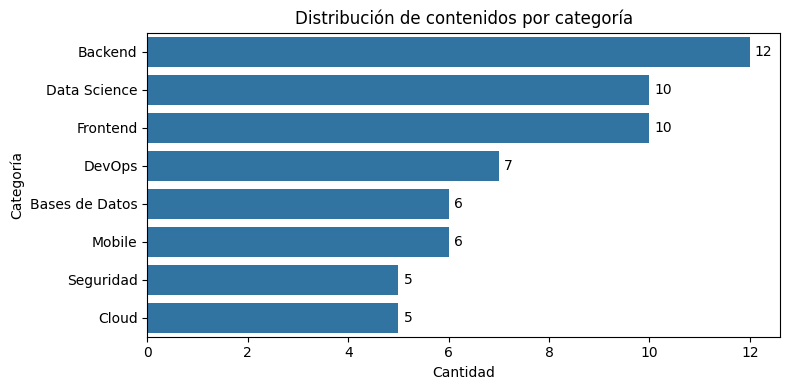

In [551]:
# Distribución de categorías
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, y="categoria", order=df["categoria"].value_counts().index)
plt.title("Distribución de contenidos por categoría")
plt.xlabel("Cantidad")
plt.ylabel("Categoría")

# Añade etiquetas de recuento junto a las barras
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.1, p.get_y() + p.get_height() / 2, f'{int(width)}', va='center')

plt.tight_layout()
plt.show()

In [552]:
df["palabras"] = df["texto"].astype(str).apply(lambda x: x.split())
df["Cantidad de palabras"] = df["texto"].apply(lambda x: len(x.split()))
df[["texto", "palabras", "Cantidad de palabras"]].head(61)

,texto,palabras,Cantidad de palabras
0,En este contenido se presentan los conceptos b...,"[En, este, contenido, se, presentan, los, conc...",19
1,Se describen los principios de diseño de micro...,"[Se, describen, los, principios, de, diseño, d...",19
2,"Tutorial sobre subconsultas, joins y funciones...","[Tutorial, sobre, subconsultas,, joins, y, fun...",13
3,Se explica cómo construir pipelines reproducib...,"[Se, explica, cómo, construir, pipelines, repr...",13
4,"Se explican los hooks useState, useEffect y us...","[Se, explican, los, hooks, useState,, useEffec...",18
...,...,...,...
56,Tutorial sobre la implementación de notificaci...,"[Tutorial, sobre, la, implementación, de, noti...",11
57,Tutorial sobre CSS Grid y Flexbox para crear d...,"[Tutorial, sobre, CSS, Grid, y, Flexbox, para,...",19
58,"Se describen métricas como precisión, recall, ...","[Se, describen, métricas, como, precisión,, re...",16
59,Se presentan las vulnerabilidades más comunes ...,"[Se, presentan, las, vulnerabilidades, más, co...",15


In [553]:
import numpy as np

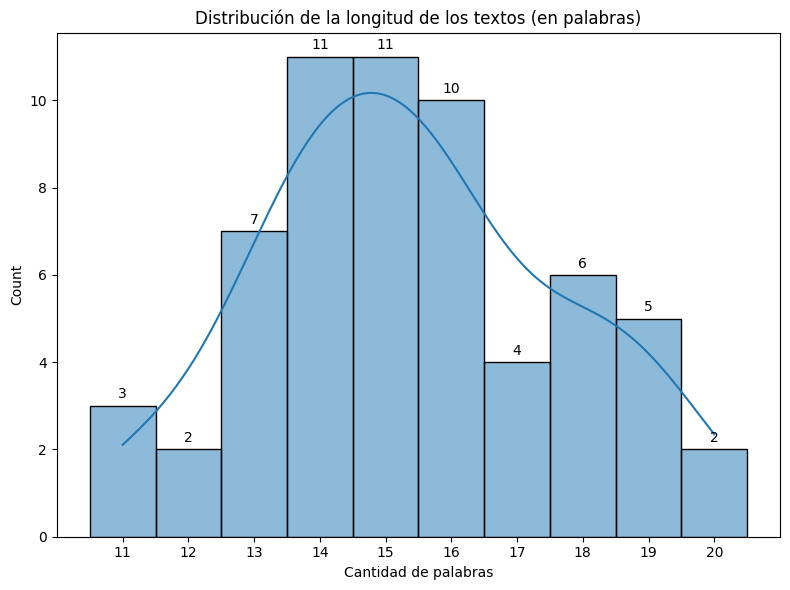

,longitud_texto
count,61.000000
mean,15.377049
std,2.259527
min,11.000000
25%,14.000000
50%,15.000000
75%,17.000000
max,20.000000


In [554]:
df["longitud_texto"] = df["texto"].apply(lambda x: len(x.split()))
plt.figure(figsize=(8, 6))

min_val = int(df["longitud_texto"].min())
max_val = int(df["longitud_texto"].max())
bins = np.arange(min_val - 0.5, max_val + 1.5, 1)

ax = sns.histplot(df["longitud_texto"], bins=bins, kde=True)

plt.title("Distribución de la longitud de los textos (en palabras)")
plt.xlabel("Cantidad de palabras")

xticks = []
for p in ax.patches:
  height = p.get_height()
  if height > 0:
    center = p.get_x() + p.get_width() / 2
    xticks.append(int(round(center)))
    ax.text(center, height + 0.1, f"{int(height)}", ha="center", va="bottom")

ax.set_xticks(xticks)

plt.tight_layout()
plt.show()

df["longitud_texto"].describe()



*   **Conteo (Count):** 61
*   **Media (Mean):** 15.38 palabras
*   **Desviación Estándar (Standard Deviation):** 2.26 palabras
*   **Mínimo (Minimum):** 11 palabras
*   **Percentil 25 (25% Percentile):** 14 palabras
*   **Mediana (50% Percentile):** 15 palabras
*   **Percentil 75 (75% Percentile):** 17 palabras
*   **Máximo (Maximum):** 20 palabras

## 4. Preprocesamiento de texto

Combinamos `titulo` + `texto` en un solo campo (el título suele traer términos muy
discriminantes) y aplicamos una limpieza básica: minúsculas, remoción de puntuación y de
stopwords en español.

In [555]:
import re

In [556]:
STOPWORDS_ES = {
    "el","la","los","las","un","una","unos","unas","de","del","al","a","en","y","o",
    "que","con","para","por","se","su","sus","es","son","este","esta","estos","estas",
    "como","más","mas","muy","entre","sobre","desde","hasta","tambien","también","ser",
    "utilizando","utiliza","permite","se explican","se explica","se presenta","se presentan",
    "contenido","introduccion","introducción","tutorial","cómo","como","así","asi",
}

def limpiar_texto(texto: str) -> str:
    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúñü0-9\s]", " ", texto)
    palabras = texto.split()
    palabras = [p for p in palabras if p not in STOPWORDS_ES and len(p) > 2]
    return " ".join(palabras)

df["texto_completo"] = df["titulo"] + ". " + df["texto"]
df["texto_limpio"] = df["texto_completo"].apply(limpiar_texto)
df[["titulo", "texto_limpio"]].head(61)

,titulo,texto_limpio
0,Introducción a Spring Boot,spring boot presentan conceptos básicos creaci...
1,Arquitectura de microservicios,arquitectura microservicios describen principi...
2,Consultas avanzadas en SQL,consultas avanzadas sql subconsultas joins fun...
3,Pipelines de Scikit-Learn,pipelines scikit learn explica construir pipel...
4,Hooks de React explicados,hooks react explicados explican hooks usestate...
...,...,...
56,Notificaciones push en apps móviles,notificaciones push apps móviles implementació...
57,Diseño responsive con CSS Grid,diseño responsive css grid css grid flexbox cr...
58,Métricas de evaluación de modelos,métricas evaluación modelos describen métricas...
59,Fundamentos de OWASP Top 10,fundamentos owasp top presentan vulnerabilidad...


**Nota sobre el dataset:** este CSV (contenidos_tecnicos.csv) es un dataset sintético de ejemplo con ~60 registros repartidos en 8 categorías técnicas, pensado para dejar el pipeline completo funcionando de punta a punta. Para el MVP real del hackathon conviene ampliarlo sumando contenidos propios: descripciones de documentación oficial, resúmenes de cursos, artículos técnicos (Medium, Baeldung, dev.to, documentación de frameworks), etc. Cuantos más ejemplos por categoría, mejor generalizará el modelo — con 60 filas el modelo funciona pero tiene poco margen frente a textos muy distintos a los de entrenamiento.

## 5. Vectorización TF-IDF

In [557]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [558]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=1500, # Limita el tamaño del vocabulario a las 1,500 palabras/frases más relevantes. Esto ayuda a reducir la memoria utilizada y evita ruido o sobreajuste (overfitting)
    ngram_range=(1, 2), # Define la longitud de las secuencias de palabras a considerar: 1. (unigramas): Palabras sueltas (ej: "api", "rest"). 2. (bigramas): Pares de palabras consecutivas (ej: "api rest", "base datos"). Esto permite capturar el significado de términos compuestos
    min_df=1, # (Minimum Document Frequency): Requiere que un término aparezca al menos en 1 documento para incluirlo en el vocabulario.
)
# fit_transform(...): Realiza dos acciones en un solo paso: 1. fit: Analiza la columna df["texto_limpio"] para construir el vocabulario y calcular los pesos IDF de cada palabra/bigrama. 2. transform: Convierte cada fila de texto en un vector numérico con las puntuaciones TF-IDF
X = tfidf_vectorizer.fit_transform(df["texto_limpio"]) # X: Es la matriz numérica resultante de características (features). Será la entrada del modelo
y = df["categoria"] # y: Es la variable objetivo o etiqueta (target), en este caso la columna categoria (por ejemplo: "Backend", "Frontend", "Data Science"), que el modelo aprenderá a predecir a partir de X

print("Matriz TF-IDF:", X.shape) # X.shape: Muestra la forma de la matriz resultante en formato (filas, columnas): Filas: Número de documentos/textos procesados en el DataFrame. Columnas: Cantidad de términos únicos seleccionados para el vocabulario (hasta un máximo de 1,500)

# Resumen: se está convirtiendo el listado de textos limpios (df["texto_limpio"]) en una gran tabla matemática (X) donde cada fila es un texto y cada columna es una palabra o frase corta de importancia. Esta matriz X junto con las respuestas correctas y servirán para entrenar un modelo de clasificación

Matriz TF-IDF: (61, 1013)


-61: (Filas / Registros): hay 61 textos o artículos en el DataFrame

-1013: (Columnas / Características): El vectorizador encontró 1,013 palabras o frases compuestas únicas (unigramas y bigramas) entre todos los textos

## 6. División train/test y entrenamiento del modelo

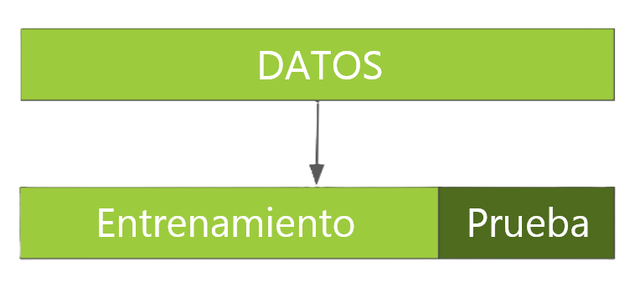

In [559]:
from sklearn.model_selection import train_test_split

In [560]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

## 7. Evaluación del modelo

In [561]:
from sklearn.linear_model import LogisticRegression

In [562]:
from sklearn.metrics import ConfusionMatrixDisplay

In [563]:
from sklearn.metrics import classification_report

                precision    recall  f1-score   support

       Backend       0.43      1.00      0.60         3
Bases de Datos       0.50      1.00      0.67         1
         Cloud       1.00      1.00      1.00         1
  Data Science       1.00      1.00      1.00         3
        DevOps       0.00      0.00      0.00         2
      Frontend       1.00      0.33      0.50         3
        Mobile       1.00      1.00      1.00         2
     Seguridad       0.00      0.00      0.00         1

      accuracy                           0.69        16
     macro avg       0.62      0.67      0.60        16
  weighted avg       0.67      0.69      0.62        16



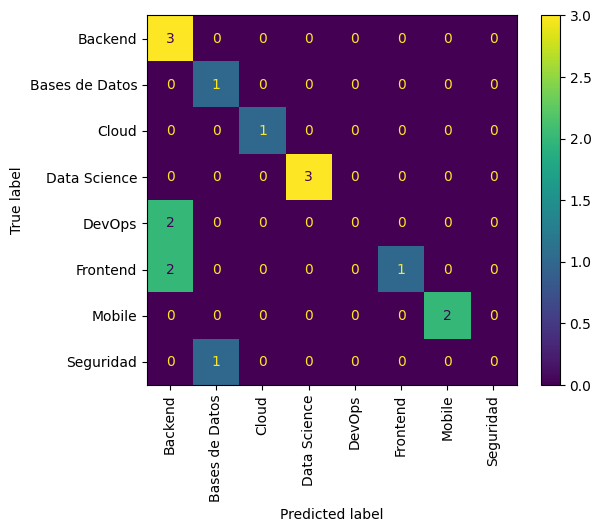

In [564]:
modelo = LogisticRegression(max_iter=1000, class_weight="balanced")
modelo.fit(X_train, y_train)
y_previsto_modelo = modelo.predict(X_test)

print(classification_report(y_test, y_previsto_modelo, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_previsto_modelo, xticks_rotation=90)
plt.show()

**Sobre el dataset pequeño:** con ~60 ejemplos el `test_size` deja pocas muestras por
categoría, así que estas métricas son orientativas. El pipeline (limpieza → TF-IDF →
Regresión Logística → evaluación) es el que importa mantener; al ampliar el dataset real
del equipo, estas mismas celdas ya quedan listas para volver a correr.

## 8. Extracción de palabras clave (`informaciones_adicionales`)

Para las keywords no usamos la predicción del modelo, sino los términos con **mayor peso
TF-IDF dentro del propio documento** (independientemente de la categoría). Esto es lo que en
la consigna se pide como "identificación de palabras clave" y sirve tanto si el documento
está bien clasificado como si no.

In [565]:
def extraer_keywords(texto_limpio: str, vectorizer: TfidfVectorizer, top_n: int = 5):
    """Devuelve las top_n palabras/n-gramas con mayor peso TF-IDF en el documento."""
    vector = vectorizer.transform([texto_limpio])
    feature_names = vectorizer.get_feature_names_out()
    scores = vector.toarray()[0]

    top_indices = scores.argsort()[::-1][:top_n]
    keywords = [feature_names[i] for i in top_indices if scores[i] > 0]
    return keywords

# Prueba rápida
ejemplo = df.iloc[0]
print("Texto:", ejemplo["titulo"])
print("Keywords:", extraer_keywords(ejemplo["texto_limpio"], tfidf_vectorizer))

Texto: Introducción a Spring Boot
Keywords: ['boot', 'spring boot', 'spring', 'creación apis', 'java spring']


## 9. Función de inferencia end-to-end (lo que consumirá el back-end)

In [566]:
import json

In [567]:
def procesar_contenido(titulo: str, texto: str, top_n_keywords: int = 5) -> dict:
    """
    Replica lo que hará el endpoint POST /contenido:
    recibe titulo + texto y devuelve categoria, probabilidad y keywords.
    """
    texto_completo = f"{titulo}. {texto}"
    texto_limpio = limpiar_texto(texto_completo)

    vector = tfidf_vectorizer.transform([texto_limpio])

    categoria_predicha = modelo.predict(vector)[0]
    probabilidades = modelo.predict_proba(vector)[0]
    probabilidad = float(np.max(probabilidades))

    keywords = extraer_keywords(texto_limpio, tfidf_vectorizer, top_n=top_n_keywords)

    return {
        "categoria": categoria_predicha,
        "probabilidad": round(probabilidad, 4),
        "informaciones_adicionales": keywords,
    }

# Ejemplo igual al de la consigna
resultado = procesar_contenido(
    "Introducción a Spring Boot",
    "Conceptos básicos para la creación de APIs REST con Java y Spring Boot."
)
print(json.dumps(resultado, indent=2, ensure_ascii=False))

{
  "categoria": "Backend",
  "probabilidad": 0.2779,
  "informaciones_adicionales": [
    "boot",
    "spring boot",
    "spring",
    "creación apis",
    "java spring"
  ]
}


## 10. Tres ejemplos de uso documentados (requisito del MVP)

In [568]:
ejemplos = [
    {
        "titulo": "Introducción a Spring Boot",
        "texto": "Conceptos básicos para la creación de APIs REST con Java y Spring Boot.",
    },
    {
        "titulo": "Limpieza y transformación de datos",
        "texto": "Uso de Pandas para limpiar datos faltantes, normalizar columnas y preparar un dataset para modelado.",
    },
    {
        "titulo": "Despliegue de contenedores en producción",
        "texto": "Cómo construir imágenes Docker y orquestarlas con Kubernetes para un despliegue continuo escalable.",
    },
]

for ej in ejemplos:
    salida = procesar_contenido(ej["titulo"], ej["texto"])
    print("ENTRADA:", json.dumps(ej, ensure_ascii=False))
    print("SALIDA :", json.dumps(salida, ensure_ascii=False))
    print("-" * 80)

ENTRADA: {"titulo": "Introducción a Spring Boot", "texto": "Conceptos básicos para la creación de APIs REST con Java y Spring Boot."}
SALIDA : {"categoria": "Backend", "probabilidad": 0.2779, "informaciones_adicionales": ["boot", "spring boot", "spring", "creación apis", "java spring"]}
--------------------------------------------------------------------------------
ENTRADA: {"titulo": "Limpieza y transformación de datos", "texto": "Uso de Pandas para limpiar datos faltantes, normalizar columnas y preparar un dataset para modelado."}
SALIDA : {"categoria": "Data Science", "probabilidad": 0.2007, "informaciones_adicionales": ["datos", "limpieza transformación", "limpieza", "datos uso", "transformación datos"]}
--------------------------------------------------------------------------------
ENTRADA: {"titulo": "Despliegue de contenedores en producción", "texto": "Cómo construir imágenes Docker y orquestarlas con Kubernetes para un despliegue continuo escalable."}
SALIDA : {"categoria": "

## 11. Serialización del modelo

Guardamos el vectorizer y el clasificador por separado (ambos son necesarios en inferencia)
con `joblib`. Estos son los artefactos que el equipo de Back-End va a cargar desde la API
(o desde OCI Object Storage).

In [569]:
import joblib

In [570]:
import os

In [571]:
joblib.dump(tfidf_vectorizer, "/content/tfidf_vectorizer.joblib")
joblib.dump(modelo, "/content/modelo_clasificador.joblib")

print("Modelos guardados: /content/tfidf_vectorizer.joblib, modelo_clasificador.joblib")


Modelos guardados: /content/tfidf_vectorizer.joblib, modelo_clasificador.joblib


In [572]:
# Prueba de carga (simula lo que hará la API al arrancar)
vectorizer_cargado = joblib.load("/content/tfidf_vectorizer.joblib")
modelo_cargado = joblib.load("/content/modelo_clasificador.joblib")

vector_prueba = vectorizer_cargado.transform([limpiar_texto("Introducción a Spring Boot. APIs REST con Java.")])
print("Categoría:", modelo_cargado.predict(vector_prueba)[0])


Categoría: Backend


## 12. Próximos pasos / notas para la integración

- **Subida a OCI Object Storage:** subir `tfidf_vectorizer.joblib` y `modelo_clasificador.joblib`
  al bucket del proyecto; el back-end (Spring Boot) los descarga al iniciar o los sirve un
  microservicio Python (FastAPI/Flask) que exponga `POST /contenido` y sea consumido internamente
  por la API Java, según cómo defina el equipo la arquitectura.
- **Ampliar el dataset:** el dataset actual es sintético (~60 filas) para dejar el pipeline
  funcionando; conviene sumar contenidos reales (documentación, artículos, resúmenes de cursos)
  antes de la demo, sobre todo en las categorías con menos ejemplos.
- **Opcional — recomendación de contenidos relacionados:** con la misma matriz TF-IDF se puede
  calcular similaridad coseno entre documentos (`sklearn.metrics.pairwise.cosine_similarity`)
  para sugerir contenidos parecidos a uno dado.
- **Opcional — búsqueda semántica:** si da tiempo, reemplazar/complementar TF-IDF con embeddings
  (p. ej. `sentence-transformers`) mejora la búsqueda por significado en vez de por palabras exactas.
